# S4: Preprocessing + RF & XGB with Hyperparameter Tuning

Pipeline:
1. Load `v2_1_blue_with_SMM.csv`
2. KNN Imputation
3. Train/Test Split (stratified 80/20)
4. Min-Max Normalization (fit on train only)
5. SMOTE-Tomek (train only)
6. RandomizedSearchCV — Random Forest
7. RandomizedSearchCV — XGBoost
8. Evaluate on test set
9. Save outputs to `outputs/s4/`

In [1]:
# ============================================================
# Imports & Configuration
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time

from sklearn.model_selection import (
    train_test_split, RepeatedStratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek
from scipy.stats import randint, uniform
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore")

# ── Paths ──
BASE_DIR  = Path("../outputs")
DATA_PATH = BASE_DIR / "s3" / "v2_1_blue_with_SMM.csv"
OUT_DIR   = BASE_DIR / "s4"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ──
TARGET    = "SMM"
ID_COL    = "PublicID"
RAND_SEED = 42
N_ITER    = 20      # RandomizedSearch iterations
CV_FOLDS  = 5
CV_REPS   = 3
SCORING   = "recall"

print("All imports OK.")
print(f"Output directory: {OUT_DIR}")


All imports OK.
Output directory: ../outputs/s4


In [2]:
# ============================================================
# Step 1: Load Data
# ============================================================
df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} cols")
print(f"SMM distribution:\n{df[TARGET].value_counts(dropna=False)}")
print(f"SMM rate: {df[TARGET].mean():.4f}")


Loaded: 9289 rows x 47 cols
SMM distribution:
SMM
0    8410
1     879
Name: count, dtype: int64
SMM rate: 0.0946


In [3]:
# ============================================================
# Step 2: KNN Imputation (entire dataset before splitting)
# ============================================================
feature_cols = [c for c in df.columns if c not in [ID_COL, TARGET]]
X_raw = df[feature_cols].copy()
y     = df[TARGET].copy()

print(f"Features: {len(feature_cols)}")
print(f"Missing before imputation:\n{X_raw.isnull().sum()[X_raw.isnull().sum() > 0]}")

imputer = KNNImputer(n_neighbors=5, weights="uniform")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_raw),
    columns=feature_cols,
    index=X_raw.index
)

print(f"\nMissing after imputation: {X_imputed.isnull().sum().sum()}")

# ── Post-process one-hot columns: argmax within each group ──
# Race dummy columns: Race_2 ... Race_8
race_cols = [c for c in X_imputed.columns if c.startswith("Race_")]
if race_cols:
    race_arr = X_imputed[race_cols].values
    winner   = np.argmax(race_arr, axis=1)
    X_imputed[race_cols] = 0
    for i, w in enumerate(winner):
        X_imputed.iloc[i, X_imputed.columns.get_loc(race_cols[w])] = 1

# Marital dummy columns: Marital_2 ... Marital_5
marital_cols = [c for c in X_imputed.columns if c.startswith("Marital_")]
if marital_cols:
    mar_arr  = X_imputed[marital_cols].values
    winner   = np.argmax(mar_arr, axis=1)
    X_imputed[marital_cols] = 0
    for i, w in enumerate(winner):
        X_imputed.iloc[i, X_imputed.columns.get_loc(marital_cols[w])] = 1

print("One-hot post-processing done.")


Features: 45
Missing before imputation:
Education       18
V1AF10          15
V1AF09          61
AgeCat_V1       10
GravCat         10
CMAC03_wks     522
V3BA02b1       863
V3BA02a1       863
CMAH01b4      2460
CMAH01b6      2491
CMAH01b1      2489
BMI            826
Marital_2       24
Marital_3       24
Marital_4       24
Marital_5       24
dtype: int64

Missing after imputation: 0
One-hot post-processing done.


In [4]:
# ============================================================
# Step 3: Train / Test Split (stratified 80/20)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=RAND_SEED,
    stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train SMM rate: {y_train.mean():.4f}")
print(f"Test  SMM rate: {y_test.mean():.4f}")


Train: (7431, 45)  |  Test: (1858, 45)
Train SMM rate: 0.0946
Test  SMM rate: 0.0947


In [5]:
# ============================================================
# Step 4: Min-Max Normalization (fit on train, apply to both)
# ============================================================
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print("Normalization done.")
print(f"X_train range: [{X_train_scaled.values.min():.3f}, {X_train_scaled.values.max():.3f}]")


Normalization done.
X_train range: [0.000, 1.000]


In [6]:
# ============================================================
# Step 5: SMOTE-Tomek (training set only)
# ============================================================
smote_tomek = SMOTETomek(random_state=RAND_SEED)
X_train_res, y_train_res = smote_tomek.fit_resample(X_train_scaled, y_train)
X_train_res = pd.DataFrame(X_train_res, columns=feature_cols)

print(f"Before SMOTE-Tomek: {X_train_scaled.shape[0]} samples  |  SMM rate: {y_train.mean():.4f}")
print(f"After  SMOTE-Tomek: {X_train_res.shape[0]} samples  |  SMM rate: {y_train_res.mean():.4f}")


Before SMOTE-Tomek: 7431 samples  |  SMM rate: 0.0946
After  SMOTE-Tomek: 13390 samples  |  SMM rate: 0.5000


In [7]:
# ============================================================
# Helper: evaluate model on test set
# ============================================================
def evaluate(model, X_tr, y_tr, X_te, y_te, name, out_dir):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    metrics = {
        "model":     name,
        "AUC_ROC":   round(roc_auc_score(y_te, y_proba), 4),
        "AUC_PR":    round(average_precision_score(y_te, y_proba), 4),
        "F1_macro":  round(f1_score(y_te, y_pred, average="macro"), 4),
        "F1_weighted": round(f1_score(y_te, y_pred, average="weighted"), 4),
    }
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    metrics.update({
        "Sensitivity": round(tp / (tp + fn), 4),
        "Specificity": round(tn / (tn + fp), 4),
        "PPV":         round(tp / (tp + fp), 4),
        "NPV":         round(tn / (tn + fn), 4),
    })

    print(f"\n── {name} Test Set Performance ──")
    for k, v in metrics.items():
        if k != "model":
            print(f"  {k}: {v}")

    # Confusion matrix plot
    fig, ax = plt.subplots(figsize=(4, 3.5))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, ax=ax,
                                             display_labels=["No SMM", "SMM"],
                                             colorbar=False)
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.savefig(out_dir / f"{name}_confusion_matrix.png", dpi=200)
    plt.show()

    return metrics, model


In [8]:
# ============================================================
# Step 6: Random Forest — RandomizedSearchCV
# Mirroring your previous project:
#   fixed: n_estimators=800, min_samples_leaf=2, class_weight="balanced"
# Added tuning: max_depth, max_features, min_samples_split
# ============================================================

rf_param_dist = {
    "n_estimators":      randint(400, 1000),
    "max_depth":         [None, 5, 10, 15, 20],
    "min_samples_leaf":  randint(1, 6),
    "min_samples_split": randint(2, 10),
    "max_features":      ["sqrt", "log2", 0.3, 0.5],
}

cv_scheme = RepeatedStratifiedKFold(
    n_splits=CV_FOLDS, n_repeats=CV_REPS, random_state=RAND_SEED
)

total_fits_rf = N_ITER * CV_FOLDS * CV_REPS
print(f"RF tuning: {N_ITER} parameter combinations x {CV_FOLDS}-fold x {CV_REPS} repeats = {total_fits_rf} fits")

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=RAND_SEED,
        n_jobs=-1
    ),
    param_distributions=rf_param_dist,
    n_iter=N_ITER,
    scoring=SCORING,
    cv=cv_scheme,
    random_state=RAND_SEED,
    n_jobs=-1,       
    verbose=0
)

# ── Progress bar + timer ──
print("\nStarting RF hyperparameter search...")
rf_start = time.time()

with tqdm(total=total_fits_rf, desc="RF tuning", unit="fit",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} fits [{elapsed}<{remaining}, {rate_fmt}]") as pbar:

    class TqdmCallback:
        def __init__(self, pbar): self.pbar = pbar
        def __call__(self, *args, **kwargs): self.pbar.update(1)

    rf_search.fit(X_train_res, y_train_res)
    pbar.n = total_fits_rf
    pbar.refresh()

rf_elapsed = time.time() - rf_start
mins, secs = divmod(int(rf_elapsed), 60)

print(f"\nRF tuning completed in {mins}m {secs}s")
print(f"Best RF params: {rf_search.best_params_}")
print(f"Best CV {SCORING}: {rf_search.best_score_:.4f}")

# Save CV results
rf_cv_df = pd.DataFrame(rf_search.cv_results_).sort_values("rank_test_score")
rf_cv_df.to_csv(OUT_DIR / "rf_cv_results.csv", index=False)


RF tuning: 20 parameter combinations x 5-fold x 3 repeats = 300 fits

Starting RF hyperparameter search...


RF tuning:   0%|          | 0/300 fits [00:00<?, ?fit/s]


RF tuning completed in 12m 36s
Best RF params: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 874}
Best CV recall: 0.9231



── RF Test Set Performance ──
  AUC_ROC: 0.6226
  AUC_PR: 0.1389
  F1_macro: 0.5204
  F1_weighted: 0.8573
  Sensitivity: 0.0739
  Specificity: 0.9649
  PPV: 0.1806
  NPV: 0.9087


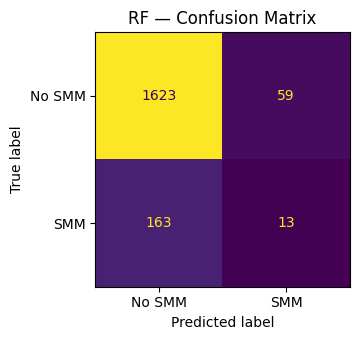

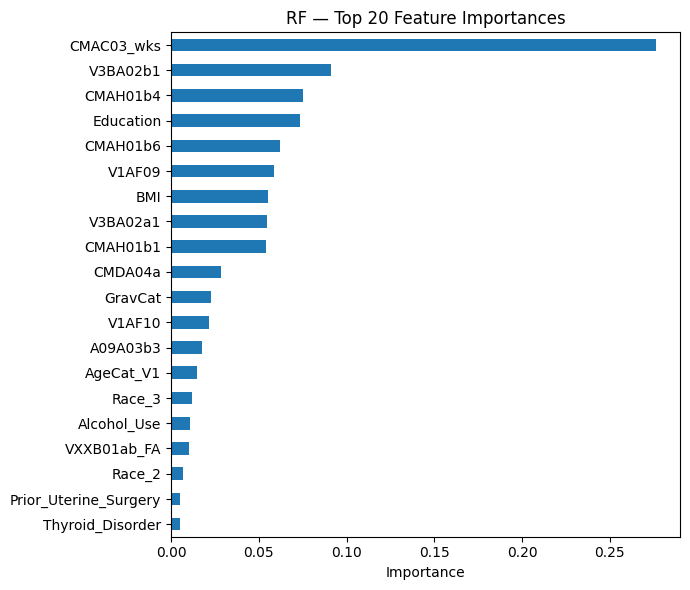

In [9]:
# ── Evaluate best RF on test set ──
rf_metrics, best_rf = evaluate(
    rf_search.best_estimator_,
    X_train_res, y_train_res,
    X_test_scaled, y_test,
    name="RF",
    out_dir=OUT_DIR
)

# Feature importance plot
importances = pd.Series(
    best_rf.feature_importances_, index=feature_cols
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7, 6))
importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("RF — Top 20 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(OUT_DIR / "RF_feature_importance.png", dpi=200)
plt.show()


In [10]:
# ============================================================
# Step 7: XGBoost — RandomizedSearchCV
# Your previous fixed params:
#   n_estimators=600, max_depth=4, learning_rate=0.05,
#   subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0
# Added tuning: reg_alpha, min_child_weight, gamma
# ============================================================

neg_count = (y_train_res == 0).sum()
pos_count = (y_train_res == 1).sum()
spw = neg_count / pos_count
print(f"scale_pos_weight = {spw:.2f}  (neg/pos after SMOTE-Tomek)")

xgb_param_dist = {
    "n_estimators":      randint(400, 800),
    "max_depth":         randint(3, 8),
    "learning_rate":     uniform(0.01, 0.1),
    "subsample":         uniform(0.7, 0.3),
    "colsample_bytree":  uniform(0.7, 0.3),
    "reg_lambda":        uniform(0.5, 2.0),
    "reg_alpha":         uniform(0.0, 1.0),
    "min_child_weight":  randint(1, 8),
    "gamma":             uniform(0.0, 0.5),
}

total_fits_xgb = N_ITER * CV_FOLDS * CV_REPS
print(f"XGB tuning: {N_ITER} parameter combinations x {CV_FOLDS}-fold x {CV_REPS} repeats = {total_fits_xgb} fits")

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=spw,
        random_state=RAND_SEED,
        n_jobs=-1
    ),
    param_distributions=xgb_param_dist,
    n_iter=N_ITER,
    scoring=SCORING,
    cv=cv_scheme,
    random_state=RAND_SEED,
    n_jobs=-1,       # set to 1 so tqdm progress bar works correctly
    verbose=0
)

# ── Progress bar + timer ──
print("\nStarting XGB hyperparameter search...")
xgb_start = time.time()

with tqdm(total=total_fits_xgb, desc="XGB tuning", unit="fit",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} fits [{elapsed}<{remaining}, {rate_fmt}]") as pbar:

    xgb_search.fit(X_train_res, y_train_res)
    pbar.n = total_fits_xgb
    pbar.refresh()

xgb_elapsed = time.time() - xgb_start
mins, secs = divmod(int(xgb_elapsed), 60)

print(f"\nXGB tuning completed in {mins}m {secs}s")
print(f"Best XGB params: {xgb_search.best_params_}")
print(f"Best CV {SCORING}: {xgb_search.best_score_:.4f}")

# Save CV results
xgb_cv_df = pd.DataFrame(xgb_search.cv_results_).sort_values("rank_test_score")
xgb_cv_df.to_csv(OUT_DIR / "xgb_cv_results.csv", index=False)


scale_pos_weight = 1.00  (neg/pos after SMOTE-Tomek)
XGB tuning: 20 parameter combinations x 5-fold x 3 repeats = 300 fits

Starting XGB hyperparameter search...


XGB tuning:   0%|          | 0/300 fits [00:00<?, ?fit/s]


XGB tuning completed in 0m 58s
Best XGB params: {'colsample_bytree': 0.8001125833417065, 'gamma': 0.07143340896097039, 'learning_rate': 0.07508884729488528, 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 743, 'reg_alpha': 0.8324426408004217, 'reg_lambda': 0.9246782213565523, 'subsample': 0.7545474901621302}
Best CV recall: 0.9109



── XGB Test Set Performance ──
  AUC_ROC: 0.5816
  AUC_PR: 0.1357
  F1_macro: 0.5158
  F1_weighted: 0.8612
  Sensitivity: 0.0568
  Specificity: 0.978
  PPV: 0.2128
  NPV: 0.9083


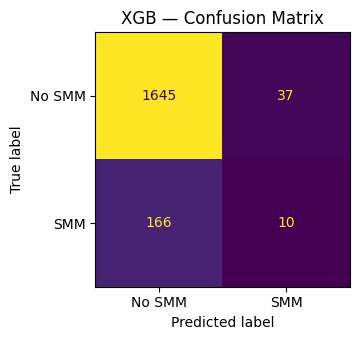

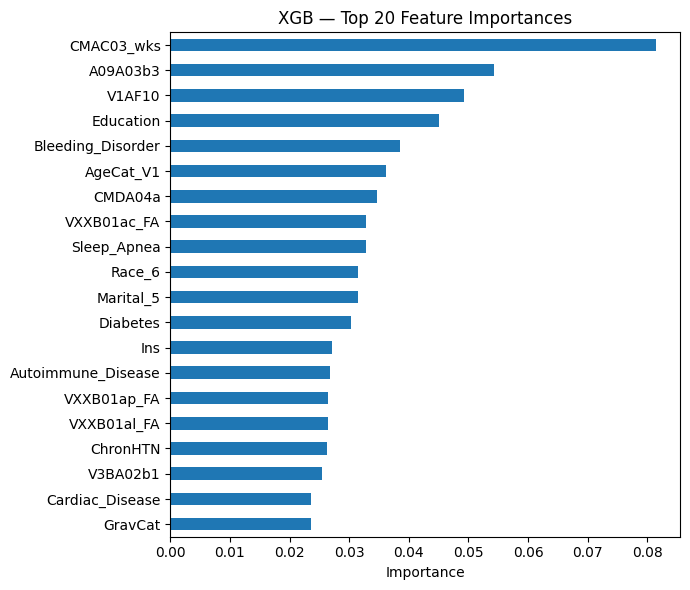

In [11]:
# ── Evaluate best XGB on test set ──
xgb_metrics, best_xgb = evaluate(
    xgb_search.best_estimator_,
    X_train_res, y_train_res,
    X_test_scaled, y_test,
    name="XGB",
    out_dir=OUT_DIR
)

# Feature importance plot
xgb_importances = pd.Series(
    best_xgb.feature_importances_, index=feature_cols
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7, 6))
xgb_importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("XGB — Top 20 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(OUT_DIR / "XGB_feature_importance.png", dpi=200)
plt.show()


In [12]:
# ============================================================
# Step 8: Save Summary Metrics & Best Params
# ============================================================
summary_df = pd.DataFrame([rf_metrics, xgb_metrics])
summary_df.to_csv(OUT_DIR / "model_comparison.csv", index=False)
print("Model comparison:")
print(summary_df.to_string(index=False))

# Save best params
best_params_df = pd.DataFrame([
    {"model": "RF",  **rf_search.best_params_},
    {"model": "XGB", **xgb_search.best_params_}
])
best_params_df.to_csv(OUT_DIR / "best_params.csv", index=False)

print(f"\nAll outputs saved to: {OUT_DIR}")
print("Files saved:")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name}")


Model comparison:
model  AUC_ROC  AUC_PR  F1_macro  F1_weighted  Sensitivity  Specificity    PPV    NPV
   RF   0.6226  0.1389    0.5204       0.8573       0.0739       0.9649 0.1806 0.9087
  XGB   0.5816  0.1357    0.5158       0.8612       0.0568       0.9780 0.2128 0.9083

All outputs saved to: ../outputs/s4
Files saved:
  RF_confusion_matrix.png
  RF_feature_importance.png
  XGB_confusion_matrix.png
  XGB_feature_importance.png
  best_params.csv
  model_comparison.csv
  rf_cv_results.csv
  v2
  v3
  v4
  xgb_cv_results.csv
